In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def runge_kutta_family(stages, time_vec, stage_vec, A_matrix, n, h, initial_conditions, function):

    t, y = np.append([initial_conditions[0], np.zeros(n - 1)]), np.append([initial_conditions[1], np.zeros(n - 1)])
    k_vec = np.zeros(len(stages))

    for k in range(n - 1): 
        for i in range(n - 1):
            for j in range(i):

                k_vec[i] = function(t[k] + time_vec[i] * h, y[k] + sum(np.multiply(A_matrix[i, j] * k_vec[j]))*h)

        t[k + 1] = t[k] + h
        y[k + 1] = y[k] + h * sum(np.multiply(stage_vec, k_vec))

    return t, y


def rk4_cts(param, var, h, function):

    k_1 = function(param, var) 
    k_2 = function(param + h/2, var + k_1 * h/2)
    k_3 = function(param + h/2, var + k_2 * h/2)
    k_4 = function(param + h, var + h*k_3)

    k_vec = np.array([k_1, k_2, k_3, k_4])

    return k_vec

def fractured_rk4(k, param, var, h, k_vec):

    param[k + 1] = param[k] + h # n*h = simulation time 
    var[k + 1] = var[k] + h/6 * (k_vec[0] + 2*(k_vec[1] + k_vec[2]) + k_vec[3])

    return var[k + 1], param[k + 1]



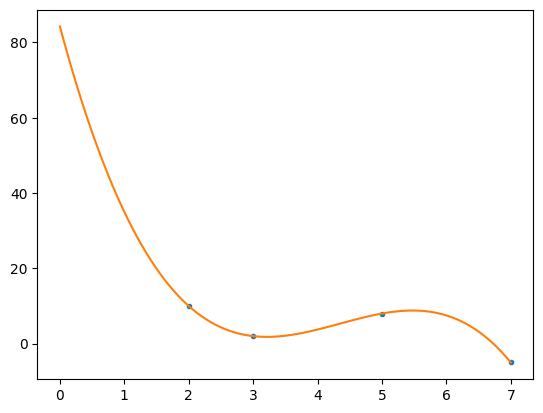

In [ ]:
def Langrange_plys(x, poles_x, poles_y):

    n = len(poles_x)

    Lagrange_basis = np.ones(n)

    for j in range(n):
        coefficients = np.ones(n)
        for m in range(n):
           if m != j:

            coefficients[m] = (x - poles_x[m])/(poles_x[j] - poles_x[m])

        Lagrange_basis[j] = np.prod(coefficients)
           

    return sum(np.multiply(poles_y, L))

def Chebyshev_nodes(n):

    nodes = np.ones(n) 
    for k in range(n):
       nodes[k] = np.cos((k + 0.5)*pi/n)

    return 


In [ ]:
def linear(x, t):
    return x